### Exporting rna for SCENIC+

RNA need to be log-normalized, and the previous object contains scaled values in adata.X

In [ ]:
import os

# Now import your libraries
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

import seaborn as sns

Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)

In [ ]:
rcParams["figure.figsize"] = (5, 5)

In [ ]:
directory = "mosaic_integration_scglue/"

In [ ]:
rna_anndata = ad.read(os.path.join(directory, "dmg_atlas_rna_full_GEX_v3.h5ad"))
rna_anndata

/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 397794 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [ ]:
print(rna_anndata.layers['counts'])

  (1, 0)	5.0
  (5, 0)	1.0
  (18, 0)	2.0
  (47, 0)	1.0
  (78, 0)	1.0
  (108, 0)	1.0
  (109, 0)	1.0
  (156, 0)	1.0
  (159, 0)	1.0
  (165, 0)	1.0
  (173, 0)	1.0
  (247, 0)	1.0
  (265, 0)	1.0
  (299, 0)	1.0
  (311, 0)	1.0
  (329, 0)	1.0
  (346, 0)	1.0
  (369, 0)	1.0
  (383, 0)	1.0
  (385, 0)	1.0
  (415, 0)	1.0
  (441, 0)	1.0
  (445, 0)	1.0
  (462, 0)	1.0
  (546, 0)	1.0
  :	:
  (396920, 19247)	1.0
  (396923, 19247)	1.0
  (397006, 19247)	1.0
  (397023, 19247)	1.0
  (397036, 19247)	1.0
  (397050, 19247)	1.0
  (397052, 19247)	1.0
  (397058, 19247)	1.0
  (397060, 19247)	1.0
  (397061, 19247)	1.0
  (397066, 19247)	1.0
  (397070, 19247)	1.0
  (397075, 19247)	1.0
  (397114, 19247)	1.0
  (397119, 19247)	1.0
  (397130, 19247)	1.0
  (397141, 19247)	1.0
  (397181, 19247)	1.0
  (397188, 19247)	1.0
  (397217, 19247)	1.0
  (397220, 19247)	1.0
  (397228, 19247)	1.0
  (397231, 19247)	1.0
  (397389, 19247)	1.0
  (397487, 19247)	1.0


In [ ]:
rna_anndata.X, rna_anndata.X.data

(array([[-0.20920948, -0.04209522, -0.46742258, ...,  0.45855098,
         -0.26919565,  0.35292056],
        [ 6.93713097, -0.04209522, -0.46742258, ...,  0.60742597,
         -0.26919565,  1.21262434],
        [-0.20920948, -0.04209522,  0.23010227, ..., -0.45210292,
         -0.26919565,  0.63529951],
        ...,
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516],
        [-0.20920948, -0.04209522, -0.46742258, ..., -0.45210292,
         -0.26919565, -0.48164516]]),
 <memory at 0x7fe49c5af9f0>)

In [ ]:
rna_anndata.X = rna_anndata.layers["counts"].copy()

rna_anndata.obs['MP_rna'] = rna_anndata.obs['MP']

In [ ]:
rna_anndata.X, rna_anndata.X.data

(<397794x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 835603632 stored elements in Compressed Sparse Column format>,
 array([5., 1., 2., ..., 1., 1., 1.]))

In [ ]:
rna_anndata.raw = rna_anndata

In [ ]:
sc.pp.normalize_total(rna_anndata, target_sum=1e4)
sc.pp.log1p(rna_anndata)

In [ ]:
rna_anndata.X, rna_anndata.X.data

(<397794x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 835603632 stored elements in Compressed Sparse Column format>,
 array([1.87739963, 1.03950589, 1.89289625, ..., 2.47696901, 2.83321334,
        2.96785656]))

In [ ]:
rna_anndata.write('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/pyscenic_dmg_atlas/dmg_rna_atlas_v4.h5ad',
                 compression='gzip')

## Running SCENIC+

In [ ]:
!scenicplus


   ____   ____ _____ _   _ ___ ____      
  / ___| / ___| ____| \ | |_ _/ ___| _ 
  \___ \| |   |  _| |  \| || | |   _|.|_
   ___) | |___| |___| |\  || | |__|_..._|
  |____/ \____|_____|_| \_|___\____||_| 


scenicplus verions: 1.0a1
usage: scenicplus [-h] {init_snakemake,prepare_data,grn_inference} ...

Single-Cell Enhancer-driven gene regulatory Network Inference and Clustering

positional arguments:
  {init_snakemake,prepare_data,grn_inference}

options:
  -h, --help            show this help message and exit


In [ ]:
!tree scplus_pipeline_atlas/

scplus_pipeline_atlas/
└── Snakemake
    ├── config
    │   └── config.yaml
    └── workflow
        └── Snakefile

3 directories, 2 files


In [ ]:
!mkdir -p outs
!mkdir -p tmp

In [ ]:
!tree /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/pyscenic_dmg_atlas/region_sets

/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/pyscenic_dmg_atlas/region_sets
├── DARs_cell_type
│   ├── ACLike.bed
│   ├── Astrocyte.bed
│   ├── C1Q.bed
│   ├── CiliaLike.bed
│   ├── COPLike.bed
│   ├── Endothelial.bed
│   ├── GBlike.bed
│   ├── GWLike.bed
│   ├── Homeostatic.bed
│   ├── IL1B.bed
│   ├── IPCLike.bed
│   ├── LipidLaden.bed
│   ├── Lymphoid.bed
│   ├── MonoNeutrophil.bed
│   ├── Mural.bed
│   ├── Neuron.bed
│   ├── Oligodendrocyte.bed
│   ├── OPC.bed
│   ├── OPCLike.bed
│   ├── RGLike.bed
│   ├── Scavenger.bed
│   ├── TDLike.bed
│   └── TriIPCLike.bed
├── Topics_otsu
│   ├── Topic100.bed
│   ├── Topic10.bed
│   ├── Topic11.bed
│   ├── Topic12.bed
│   ├── Topic13.bed
│   ├── Topic14.bed
│   ├── Topic15.bed
│   ├── Topic16.bed
│   ├── Topic17.bed
│   ├── Topic18.bed
│   ├── Topic19.bed
│   ├── Topic1.bed
│   ├── Topic20.bed
│   ├── Topic21.bed
│   ├── Topic22.bed
│   ├── Topic23.bed
│   ├── Topic24.bed
│   ├── Topic25.bed
│   ├── Topic26.bed
│   ├── Topic27.bed
│   

In [ ]:
!bat scplus_pipeline_atlas/Snakemake/config/config.yaml

───────┬────────────────────────────────────────────────────────────────────────
       │ File: scplus_pipeline_atlas/Snakemake/config/config.yaml
───────┼────────────────────────────────────────────────────────────────────────
   1   │ input_data:
   2   │   cisTopic_obj_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/
       │ data/pyscenic_dmg_atlas/cistopic_obj.pkl"
   3   │   GEX_anndata_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/d
       │ ata/pyscenic_dmg_atlas/dmg_rna_atlas_v4.h5ad"
   4   │   region_set_folder: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/d
       │ ata/pyscenic_dmg_atlas/region_sets"
   5   │   ctx_db_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/c
       │ istargetdb/hg38_screen_v10_clust.regions_vs_motifs.rankings.feather"
   6   │   dem_db_fname: "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/c
       │ istargetdb/hg38_screen_v10_clust.regions_vs_motifs.scores.feather"
   7   │   path_to_motif_annotations: "/p

In [ ]:
cd scplus_pipeline_atlas/Snakemake/

/gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/scplus_pipeline_atlas/Snakemake


/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
ls

config/  workflow/


In [ ]:
!snakemake --cores 64
# error solved  after updating dask
# pip install dask==2024.4.1
# https://github.com/aertslab/scenicplus/issues/408
# https://github.com/aertslab/scenicplus/issues/381

Assuming unrestricted shared filesystem usage for local execution.
Building DAG of jobs...
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Using shell: /usr/bin/bash
Provided cores: 64
Rules claiming more threads will be scaled down.
Job stats:
job                             count
----------------------------  -------
AUCell_direct                       1
AUCell_extended                     1
all                                 1
download_genome_annotations         1
eGRN_direct                         1
eGRN_extended                       1
get_search_space                    1
motif_enrichment_cistarget          1
motif_enrichment_dem                1
prepare_GEX_ACC_non_multiome        1
prepare_menr                        1
region_to_gene                      1
scplus_mudata                       1
tf_to_gene                          1
total                              14

Select jobs to execute...
Execute 1 jobs...

[Mon Aug 12 16:21:32 2024

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Running using 64 cores: 100%|███████████| 19248/19248 [2:02:43<00:00,  2.61it/s]
2024-08-13 09:07:26,885 TF2G         INFO     Adding correlation coefficients to adjacencies.
2024-08-13 09:08:00,984 TF2G         INFO     Warning: adding TFs as their own target to adjecencies matrix. Importance values will be max + 1e-05
2024-08-13 09:08:06,925 SCENIC+      INFO     Saving TF to gene adjacencies to: /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/tf_to_gene_adj.tsv
[Tue Aug 13 09:08:16 2024]
Finished job 5.
8 of 14 steps (57%) done
Select jobs to execute...
Execute 1 jobs...

[Tue Aug 13 09:08:16 2024]
localrule eGRN_direct:
    input: /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/tf_to_gene_adj.tsv, /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/region_to_gene_adj.tsv, /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/outs/cistromes_direct.h5ad, /projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/cistargetdb/hg38_screen_v10_clust.regions_vs_motifs.rankings.feather
    

## Assesing outputs

In [ ]:
import os
os.chdir("/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/")

In [ ]:
import mudata
scplus_mdata = mudata.read("outs_dmg_atlas_v4//scplusmdata.h5mu")

/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/crui

In [ ]:
scplus_mdata

MuData object with n_obs × n_vars = 24924 × 395736
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	24924 x 19248
      obs:	'MP'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_version', 'gene_type', 'hgnc_id', 'tag', 'havana_gene'
    scATAC_counts:	24924 x 374422
      obs:	'MP'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	24924 x 688
    direct_region_based_AUC:	24924 x 688
    extended_gene_based_AUC:	24924 x 345
    extended_region_based_AUC:	24924 x 345

In [ ]:
scplus_mdata.uns["direct_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr3:77328874-77329915,ROBO2,0.016158,0.261483,0.004225,0.004225,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.784048,1,0.489617,170081
1,chr9:119157285-119158518,BRINP1,0.025454,0.304732,0.007757,0.007757,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.324853,1,0.173979,224335
2,chr7:14339634-14340524,DGKB,0.027651,0.621275,0.017179,0.017179,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),1.170801,1,0.384082,194709
3,chr12:110531574-110532599,TCTN1,0.052186,0.345784,0.018045,0.018045,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.743310,1,0.298236,227916
4,chr11:32087938-32089029,RCN1,0.040007,0.426300,0.017055,0.017055,AR,False,AR_direct_+/+,AR_direct_+/+_(198g),AR_direct_+/+_(293r),0.250146,1,0.237303,315361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414108,chr9:69759440-69760453,APBA1,0.007455,-0.161351,-0.001203,0.001203,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.085289,-1,-0.054241,301055
414109,chr15:83010775-83012149,HDGFL3,0.075351,-0.283573,-0.021367,0.021367,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.045916,-1,-0.065083,205931
414110,chr6:28922636-28923278,ZNF311,0.067250,-0.070306,-0.004728,0.004728,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.047548,-1,-0.050334,147611
414111,chr11:414427-415482,PTDSS2,0.072011,-0.153459,-0.011051,0.011051,ZNF846,False,ZNF846_direct_-/-,ZNF846_direct_-/-_(27g),ZNF846_direct_-/-_(56r),0.020306,-1,-0.079849,294121


In [ ]:
scplus_mdata.uns["extended_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr2:231049944-231051047,ARMC9,0.070256,0.398626,0.028006,0.028006,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),0.566140,1,0.326379,107173
1,chr4:31235777-31236895,PCDH7,0.032196,0.444975,0.014326,0.014326,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),3.620270,1,0.453750,52629
2,chr11:73257170-73259591,ARHGEF17,0.048626,0.401674,0.019532,0.019532,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),0.557222,1,0.281205,153323
3,chr1:208047106-208048589,PLXNA2,0.007376,0.367108,0.002708,0.002708,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),0.341280,1,0.303208,154005
4,chr3:77328874-77329915,ROBO2,0.016158,0.261483,0.004225,0.004225,AR,True,AR_extended_+/+,AR_extended_+/+_(197g),AR_extended_+/+_(288r),1.784048,1,0.489617,86757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219998,chr2:152717071-152718003,FMNL2,0.007245,-0.051398,-0.000372,0.000372,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.064707,-1,-0.176868,208255
219999,chr5:133051416-133052427,FSTL4,0.008822,-0.283593,-0.002502,0.002502,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.053228,-1,-0.184341,161893
220000,chr3:9933272-9934186,OGG1,0.021472,-0.065544,-0.001407,0.001407,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.044213,-1,-0.056784,56666
220001,chr19:48398274-48399195,TMEM143,0.034749,-0.116967,-0.004065,0.004065,XBP1,True,XBP1_extended_-/-,XBP1_extended_-/-_(11g),XBP1_extended_-/-_(16r),0.085539,-1,-0.079934,162851


## Downstream analysis

### eRegulon specificity score

In [ ]:
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)

In [ ]:
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:MP",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)

In [ ]:
rss

,AFF4_direct_-/-_(11g),AHR_direct_+/-_(55g),AHR_direct_-/+_(15g),AHR_direct_-/-_(37g),APEX1_direct_-/+_(24g),APEX1_direct_-/-_(14g),ARID3A_direct_+/+_(55g),ARID3A_direct_+/-_(143g),ARID3A_direct_-/+_(84g),ARNT_direct_+/-_(14g),...,UNCX_extended_+/+_(25g),VENTX_extended_+/-_(14g),XBP1_extended_+/+_(165g),XBP1_extended_-/-_(11g),YY1_extended_+/+_(26g),YY1_extended_+/-_(13g),ZBTB7A_extended_+/+_(21g),ZNF367_extended_+/-_(51g),ZNF641_extended_+/+_(50g),ZNF672_extended_+/+_(10g)
ACLike,0.190549,0.232282,0.271054,0.245104,0.235775,0.241541,0.209063,0.208568,0.266865,0.241976,...,0.221159,0.167445,0.187129,0.252381,0.192153,0.175121,0.175444,0.180622,0.202431,0.167781
Astrocyte,0.167445,0.225538,0.175734,0.179048,0.201577,0.202434,0.196271,0.193727,0.197714,0.206327,...,0.204816,0.167445,0.186920,0.206847,0.206340,0.196660,0.169128,0.167724,0.172730,0.167445
C1Q,0.169802,0.181595,0.212686,0.306323,0.177614,0.181541,0.205840,0.199730,0.168359,0.174999,...,0.167445,0.168399,0.293704,0.194272,0.216693,0.197838,0.171728,0.176074,0.240856,0.178460
COPLike,0.168943,0.239034,0.268996,0.263037,0.241154,0.229812,0.256187,0.254550,0.210160,0.217439,...,0.167593,0.167445,0.181402,0.247589,0.208510,0.195869,0.172431,0.168142,0.258370,0.167813
CiliaLike,0.168094,0.198186,0.173331,0.175168,0.193005,0.194699,0.185479,0.185438,0.184453,0.194468,...,0.199861,0.167445,0.194007,0.186092,0.194073,0.188808,0.169146,0.168519,0.171483,0.167445
Endothelial,0.199900,0.176400,0.169016,0.176623,0.179269,0.180735,0.180570,0.182267,0.171441,0.175770,...,0.167445,0.167445,0.175312,0.171511,0.179096,0.178113,0.178456,0.168052,0.171782,0.177325
GBlike,0.168006,0.227142,0.181297,0.173995,0.207968,0.209153,0.199598,0.200125,0.196871,0.210598,...,0.274744,0.167445,0.193407,0.202996,0.210188,0.206972,0.171081,0.169997,0.174284,0.167445
GWLike,0.168139,0.242555,0.191576,0.180403,0.217790,0.217711,0.215462,0.216357,0.196156,0.223673,...,0.204213,0.167445,0.205476,0.203914,0.224841,0.228166,0.175368,0.169753,0.184604,0.167445
Homeostatic,0.168556,0.178626,0.197150,0.229940,0.184913,0.187282,0.198658,0.195457,0.169937,0.183436,...,0.167445,0.167445,0.172890,0.178670,0.173288,0.172051,0.171861,0.168888,0.280456,0.169558
IL1B,0.167445,0.177192,0.195197,0.229199,0.180750,0.183046,0.196401,0.192619,0.168411,0.178041,...,0.167445,0.167445,0.190254,0.178166,0.177812,0.179284,0.170883,0.167840,0.265058,0.167445


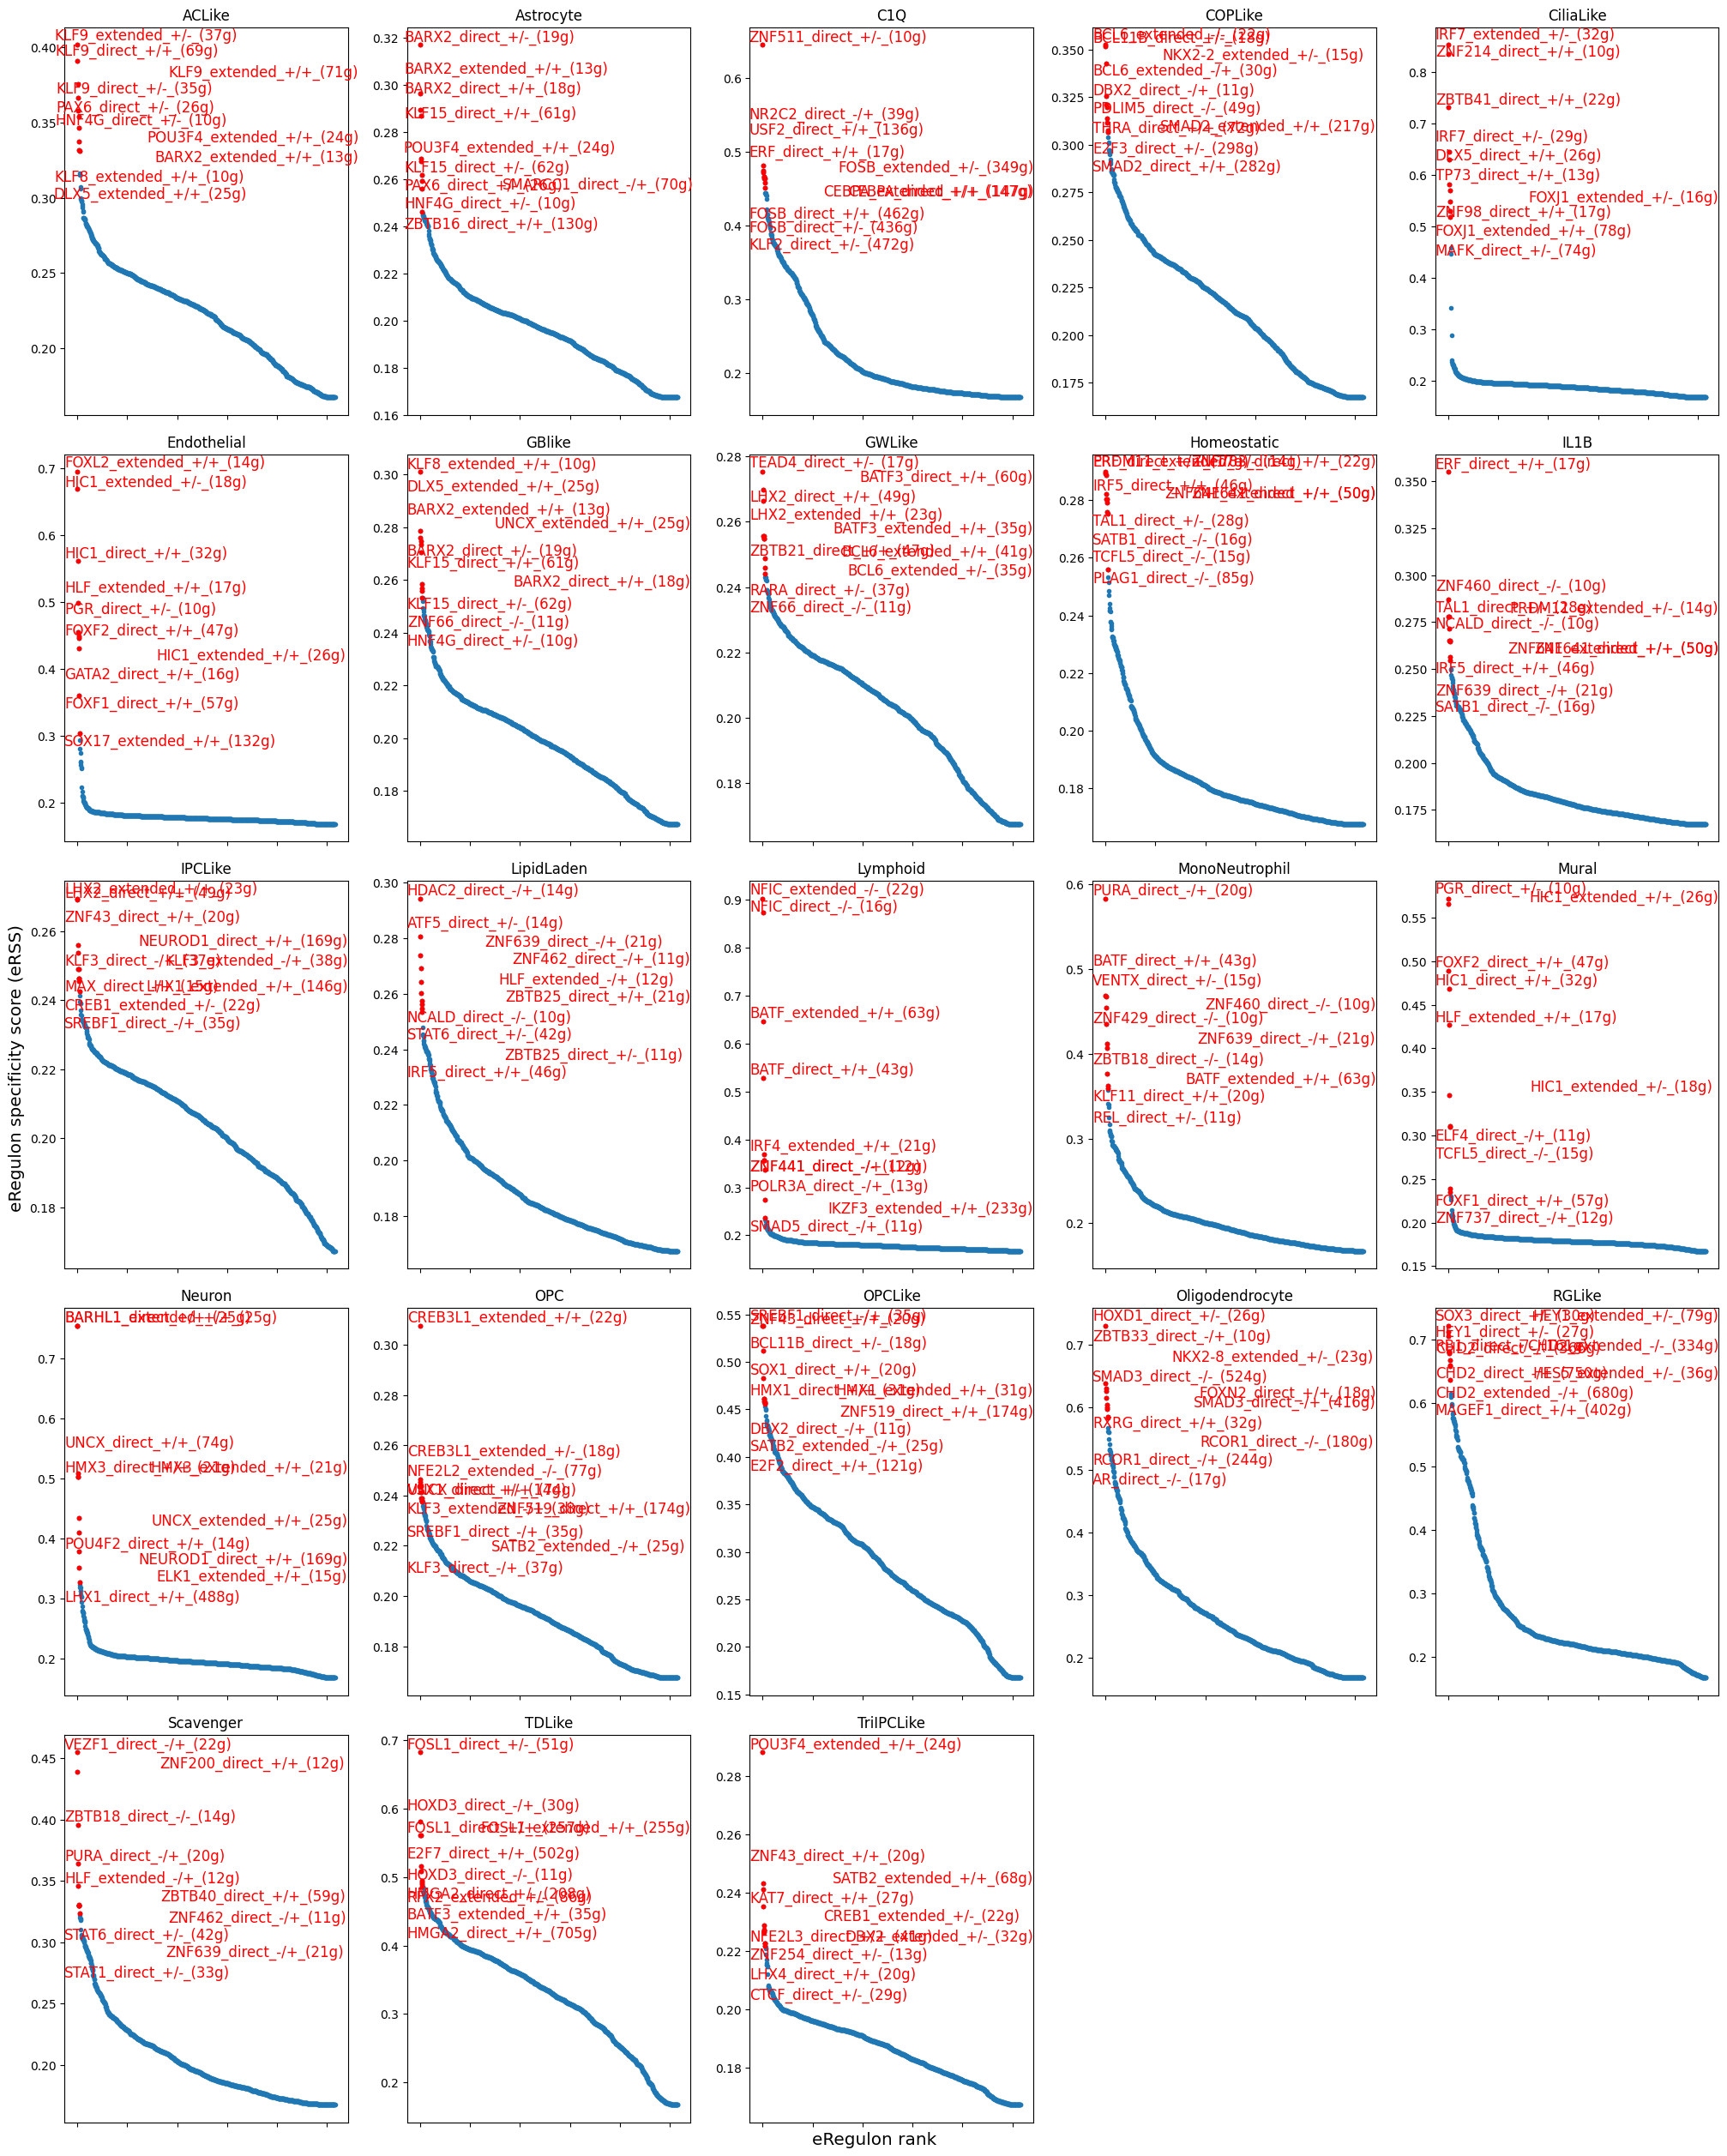

In [ ]:
plot_rss(
    data_matrix = rss,
    top_n = 10,
    num_columns = 5,
    figsize=(4,5)
)

## Converting mudata output to old-style SCENIC+ object

In [ ]:
from scenicplus.scenicplus_class import mudata_to_scenicplus

In [ ]:
scplus_obj = mudata_to_scenicplus(
    mdata = scplus_mdata,
    path_to_cistarget_h5 = "outs_dmg_atlas_v4/ctx_results.hdf5",
    path_to_dem_h5 = "outs_dmg_atlas_v4/dem_results.hdf5"
)
scplus_obj

SCENIC+ object with n_cells x n_genes = 24924 x 19248 and n_cells x n_regions = 24924 x 374422
	metadata_regions:'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
	metadata_genes:'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_version', 'gene_type', 'hgnc_id', 'tag', 'havana_gene'
	metadata_cell:'MP'
	menr:'cistarget_DARs_cell_type_ACLike', 'cistarget_DARs_cell_type_Astrocyte', 'cistarget_DARs_cell_type_C1Q', 'cistarget_DARs_cell_type_COPLike', 'cistarget_DARs_cell_type_CiliaLike', 'cistarget_DARs_cell_type_Endothelial', 'cistarget_DARs_cell_type_GBlike', 'cistarget_DARs_cell_type_GWL

In [ ]:
scplus_obj.uns

{'eRegulon_metadata':                            Region     Gene  importance_R2G   rho_R2G  \
 0          chr3:77328874-77329915    ROBO2        0.016158  0.261483   
 1        chr9:119157285-119158518   BRINP1        0.025454  0.304732   
 2          chr7:14339634-14340524     DGKB        0.027651  0.621275   
 3       chr12:110531574-110532599    TCTN1        0.052186  0.345784   
 4         chr11:32087938-32089029     RCN1        0.040007  0.426300   
 ...                           ...      ...             ...       ...   
 634111   chr2:152717071-152718003    FMNL2        0.007245 -0.051398   
 634112   chr5:133051416-133052427    FSTL4        0.008822 -0.283593   
 634113       chr3:9933272-9934186     OGG1        0.021472 -0.065544   
 634114    chr19:48398274-48399195  TMEM143        0.034749 -0.116967   
 634115       chr3:9653115-9654553     OGG1        0.036646 -0.100403   
 
         importance_x_rho  importance_x_abs_rho    TF  is_extended  \
 0               0.004225      

In [ ]:
flat_list = lambda t: [item for sublist in t for item in sublist]
selected_markers = list(set(flat_list(
    [scplus_obj.uns['eRegulon_AUC']['Region_based'].loc[celltype].sort_values(ascending = False).head(10).index.to_list() 
    for celltype in scplus_obj.uns['eRegulon_AUC']['Region_based'].index])))

In [ ]:
from scenicplus.plotting.correlation_plot import *

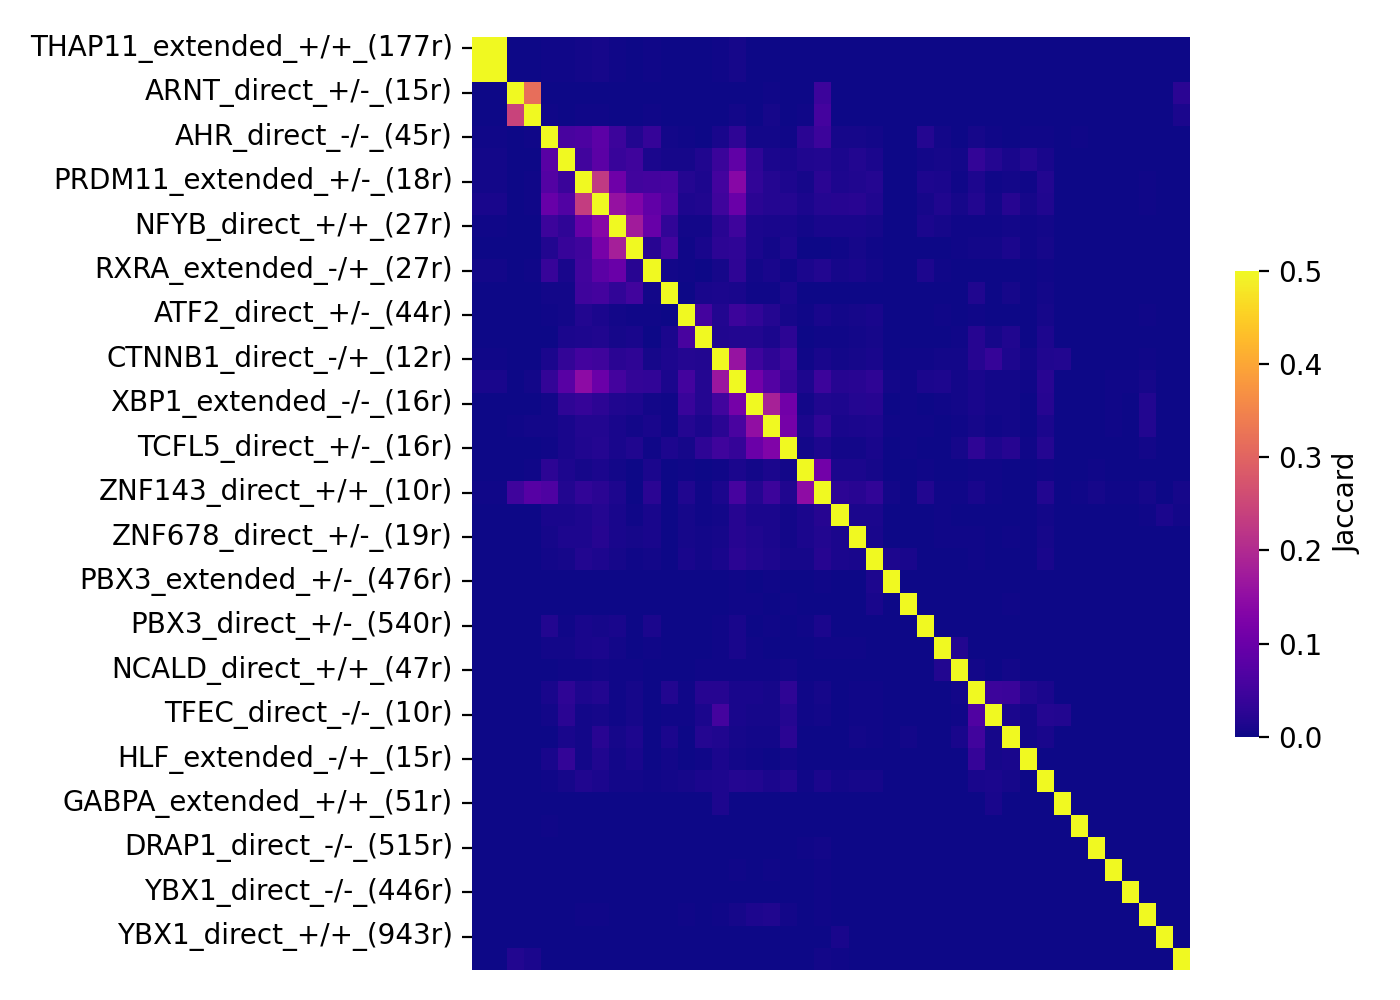

In [ ]:
region_intersetc_data, Z = jaccard_heatmap(
        scplus_obj,
        method = 'intersect',
        gene_or_region_based = 'Region_based',
        use_plotly = False,
        selected_regulons = selected_markers,
        signature_key = 'eRegulon_AUC',
        figsize = (7, 5), return_data = True, vmax = 0.5, cmap = 'plasma')

In [ ]:
from typing import List, Dict
import pandas as pd

def get_top_rss(data_matrix: pd.DataFrame, top_n: int = 5, selected_groups: List[str] = None) -> Dict[str, pd.Series]:
    """
    Get the top RSS values per group.

    Parameters
    ---------
    data_matrix: `class::pd.DataFrame`
        A pandas dataframe with RSS scores per variable.
    top_n: int, optional
        Number of top eRegulons to return.
    selected_groups: List, optional
        Groups to include. Default: None (all).

    Returns
    -------
    top_rss_dict: dict
        A dictionary with cell types as keys and top_n RSS values as pandas Series.
    """
    
    # If no groups are selected, use all available groups in the index
    if selected_groups is None:
        cats = sorted(data_matrix.index.tolist())
    else:
        cats = selected_groups
    
    top_rss_dict = {}

    # Iterate over each cell type (group)
    for c in cats:
        # Extract and sort the RSS values for the current group
        x = data_matrix.T[c]
        top_values = x.sort_values(ascending=False).head(top_n)
        
        # Store the top_n values in the dictionary
        top_rss_dict[c] = top_values

    return top_rss_dict

In [ ]:
top_rss_dict = get_top_rss(rss)
top_rss_dict

{'ACLike': KLF9_extended_+/-_(37g)    0.401722
 KLF9_direct_+/+_(69g)      0.391347
 KLF9_extended_+/+_(71g)    0.375470
 KLF9_direct_+/-_(35g)      0.366847
 PAX6_direct_+/-_(26g)      0.358011
 Name: ACLike, dtype: float64,
 'Astrocyte': BARX2_direct_+/-_(19g)       0.316839
 BARX2_extended_+/+_(13g)     0.296111
 BARX2_direct_+/+_(18g)       0.289179
 KLF15_direct_+/+_(61g)       0.286722
 POU3F4_extended_+/+_(24g)    0.268749
 Name: Astrocyte, dtype: float64,
 'C1Q': ZNF511_direct_+/-_(10g)      0.644971
 NR2C2_direct_-/+_(39g)       0.481655
 USF2_direct_+/+_(136g)       0.474894
 ERF_direct_+/+_(17g)         0.472284
 CEBPA_extended_+/+_(147g)    0.466970
 Name: C1Q, dtype: float64,
 'COPLike': BCL6_extended_-/-_(22g)      0.352320
 BCL11B_direct_+/-_(18g)      0.351780
 NKX2-2_extended_+/-_(15g)    0.342384
 BCL6_extended_-/+_(30g)      0.325472
 DBX2_direct_-/+_(11g)        0.320863
 Name: COPLike, dtype: float64,
 'CiliaLike': IRF7_extended_+/-_(32g)    0.852926
 ZNF214_direct

In [ ]:
# List of keys to filter
keys_to_subset = ['RGLike', 'GBlike', 'TriIPCLike', 'IPCLike', 'OPCLike', 'COPLike', 'ACLike', 'CiliaLike', 'GWLike', 'TDLike']

# Filter top_rss_dict for the specified keys
filtered_rss_dict = {k: v for k, v in top_rss_dict.items() if k in keys_to_subset}
filtered_rss_dict

{'ACLike': KLF9_extended_+/-_(37g)    0.401722
 KLF9_direct_+/+_(69g)      0.391347
 KLF9_extended_+/+_(71g)    0.375470
 KLF9_direct_+/-_(35g)      0.366847
 PAX6_direct_+/-_(26g)      0.358011
 Name: ACLike, dtype: float64,
 'COPLike': BCL6_extended_-/-_(22g)      0.352320
 BCL11B_direct_+/-_(18g)      0.351780
 NKX2-2_extended_+/-_(15g)    0.342384
 BCL6_extended_-/+_(30g)      0.325472
 DBX2_direct_-/+_(11g)        0.320863
 Name: COPLike, dtype: float64,
 'CiliaLike': IRF7_extended_+/-_(32g)    0.852926
 ZNF214_direct_+/+_(10g)    0.835574
 ZBTB41_direct_+/+_(22g)    0.731944
 IRF7_direct_+/-_(29g)      0.645051
 DLX5_direct_+/+_(26g)      0.629842
 Name: CiliaLike, dtype: float64,
 'GBlike': KLF8_extended_+/+_(10g)     0.300939
 DLX5_extended_+/+_(25g)     0.278698
 BARX2_extended_+/+_(13g)    0.275817
 UNCX_extended_+/+_(25g)     0.274744
 BARX2_direct_+/-_(19g)      0.273462
 Name: GBlike, dtype: float64,
 'GWLike': TEAD4_direct_+/-_(17g)      0.275313
 BATF3_direct_+/+_(60g)  

In [ ]:
tfs = [tf for series in filtered_rss_dict.values() for tf in series.index]
tfs

['KLF9_extended_+/-_(37g)',
 'KLF9_direct_+/+_(69g)',
 'KLF9_extended_+/+_(71g)',
 'KLF9_direct_+/-_(35g)',
 'PAX6_direct_+/-_(26g)',
 'BCL6_extended_-/-_(22g)',
 'BCL11B_direct_+/-_(18g)',
 'NKX2-2_extended_+/-_(15g)',
 'BCL6_extended_-/+_(30g)',
 'DBX2_direct_-/+_(11g)',
 'IRF7_extended_+/-_(32g)',
 'ZNF214_direct_+/+_(10g)',
 'ZBTB41_direct_+/+_(22g)',
 'IRF7_direct_+/-_(29g)',
 'DLX5_direct_+/+_(26g)',
 'KLF8_extended_+/+_(10g)',
 'DLX5_extended_+/+_(25g)',
 'BARX2_extended_+/+_(13g)',
 'UNCX_extended_+/+_(25g)',
 'BARX2_direct_+/-_(19g)',
 'TEAD4_direct_+/-_(17g)',
 'BATF3_direct_+/+_(60g)',
 'LHX2_direct_+/+_(49g)',
 'LHX2_extended_+/+_(23g)',
 'BATF3_extended_+/+_(35g)',
 'LHX2_extended_+/+_(23g)',
 'LHX2_direct_+/+_(49g)',
 'ZNF43_direct_+/+_(20g)',
 'NEUROD1_direct_+/+_(169g)',
 'KLF3_extended_-/+_(38g)',
 'SREBF1_direct_-/+_(35g)',
 'ZNF43_direct_+/+_(20g)',
 'BCL11B_direct_+/-_(18g)',
 'SOX1_direct_+/+_(20g)',
 'HMX1_extended_+/+_(31g)',
 'SOX3_direct_+/-_(30g)',
 'HEY1_exte

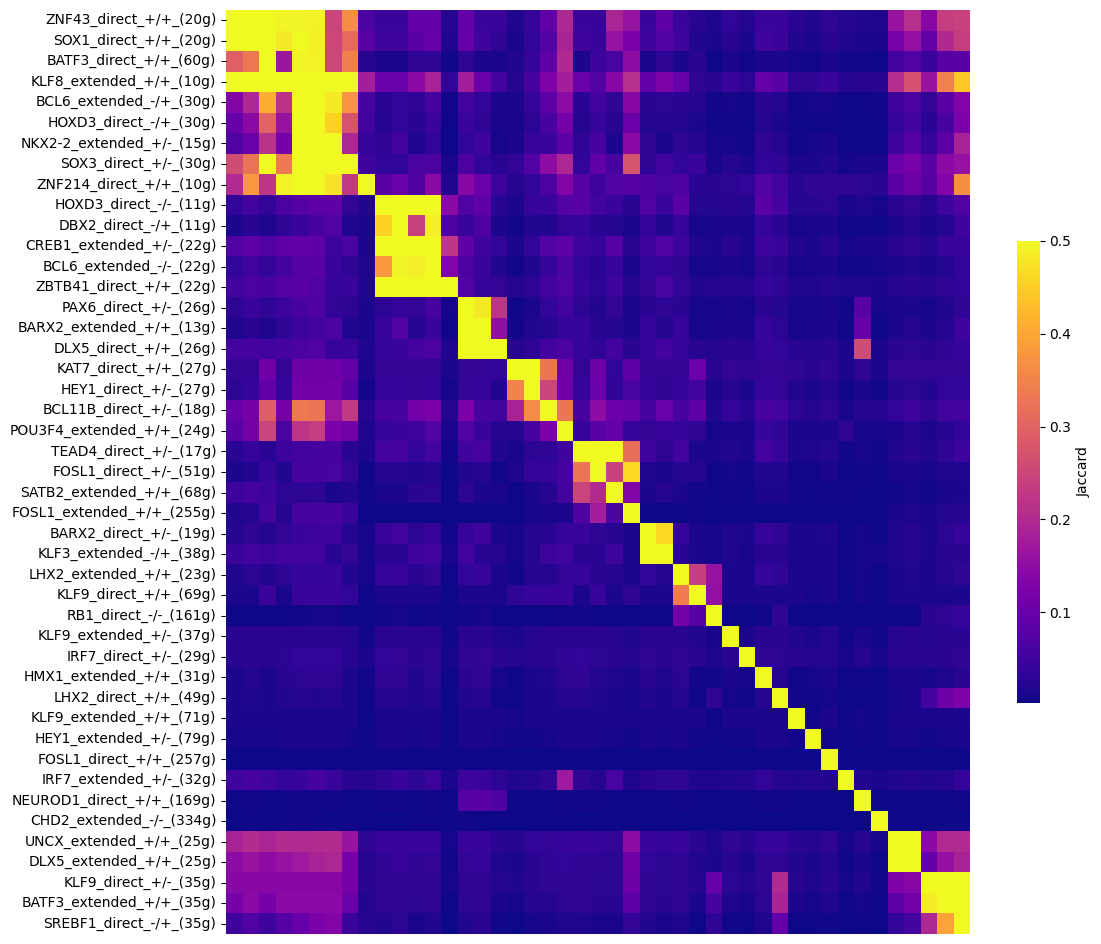

In [ ]:
region_intersetc_data, Z = jaccard_heatmap(
        scplus_obj,
        method = 'intersect',
        gene_or_region_based = 'Gene_based',
        use_plotly = False,
        selected_regulons = tfs,
        signature_key = 'eRegulon_AUC',
        figsize = (12, 12), return_data = True, vmax = 0.5, cmap = 'plasma')

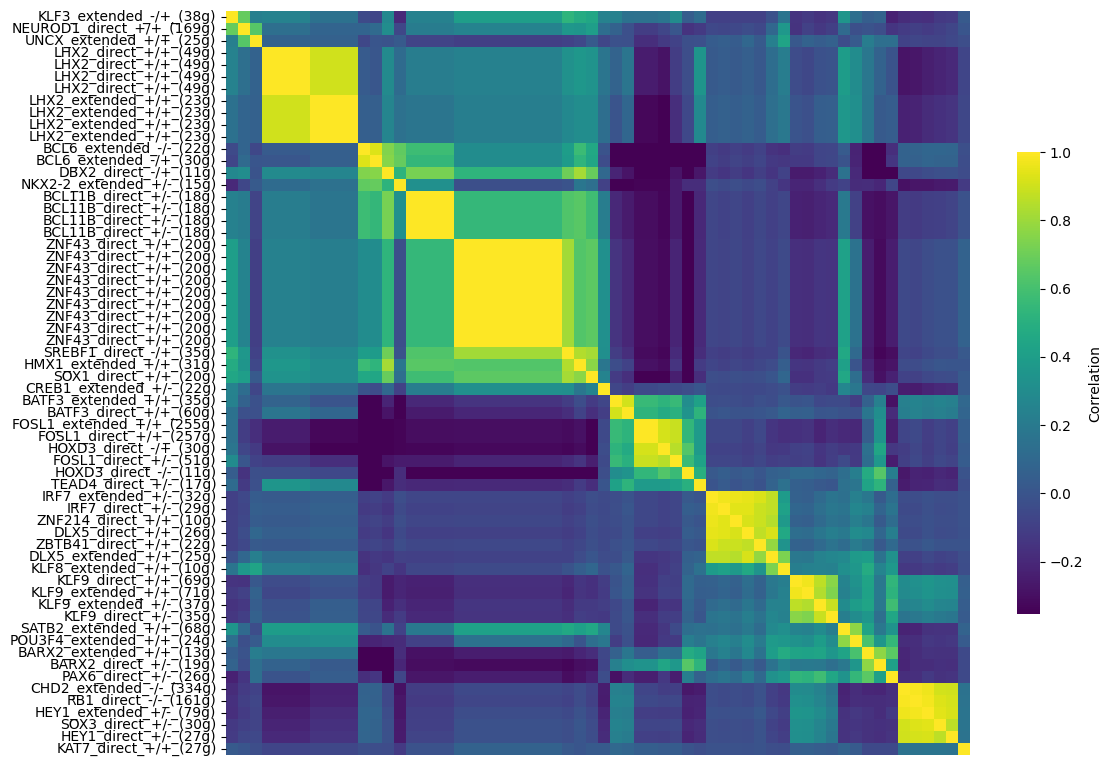

In [ ]:
correlation_heatmap(scplus_obj, selected_regulons = tfs, use_plotly=False, figsize = (12, 12))

In [ ]:
# List of keys to filter and maintain order
keys_to_subset = ['RGLike', 'GBlike', 'TriIPCLike', 'IPCLike', 'OPCLike', 'COPLike', 'ACLike', 'CiliaLike', 'GWLike', 'TDLike']

# Create a dictionary by iterating over keys_to_subset, ensuring the order is preserved
ordered_filtered_rss_dict = {k: top_rss_dict[k] for k in keys_to_subset if k in top_rss_dict}
ordered_filtered_rss_dict

{'RGLike': SOX3_direct_+/-_(30g)       0.721763
 HEY1_extended_+/-_(79g)     0.712236
 HEY1_direct_+/-_(27g)       0.705363
 CHD2_extended_-/-_(334g)    0.681095
 RB1_direct_-/-_(161g)       0.679357
 Name: RGLike, dtype: float64,
 'GBlike': KLF8_extended_+/+_(10g)     0.300939
 DLX5_extended_+/+_(25g)     0.278698
 BARX2_extended_+/+_(13g)    0.275817
 UNCX_extended_+/+_(25g)     0.274744
 BARX2_direct_+/-_(19g)      0.273462
 Name: GBlike, dtype: float64,
 'TriIPCLike': POU3F4_extended_+/+_(24g)    0.288129
 ZNF43_direct_+/+_(20g)       0.243352
 SATB2_extended_+/+_(68g)     0.241169
 KAT7_direct_+/+_(27g)        0.235364
 CREB1_extended_+/-_(22g)     0.228985
 Name: TriIPCLike, dtype: float64,
 'IPCLike': LHX2_extended_+/+_(23g)      0.269390
 LHX2_direct_+/+_(49g)        0.269038
 ZNF43_direct_+/+_(20g)       0.256056
 NEUROD1_direct_+/+_(169g)    0.253761
 KLF3_extended_-/+_(38g)      0.249053
 Name: IPCLike, dtype: float64,
 'OPCLike': SREBF1_direct_-/+_(35g)    0.538445
 ZNF43_d

In [ ]:
tfs = [tf for series in ordered_filtered_rss_dict.values() for tf in series.index]
tfs

['SOX3_direct_+/-_(30g)',
 'HEY1_extended_+/-_(79g)',
 'HEY1_direct_+/-_(27g)',
 'CHD2_extended_-/-_(334g)',
 'RB1_direct_-/-_(161g)',
 'KLF8_extended_+/+_(10g)',
 'DLX5_extended_+/+_(25g)',
 'BARX2_extended_+/+_(13g)',
 'UNCX_extended_+/+_(25g)',
 'BARX2_direct_+/-_(19g)',
 'POU3F4_extended_+/+_(24g)',
 'ZNF43_direct_+/+_(20g)',
 'SATB2_extended_+/+_(68g)',
 'KAT7_direct_+/+_(27g)',
 'CREB1_extended_+/-_(22g)',
 'LHX2_extended_+/+_(23g)',
 'LHX2_direct_+/+_(49g)',
 'ZNF43_direct_+/+_(20g)',
 'NEUROD1_direct_+/+_(169g)',
 'KLF3_extended_-/+_(38g)',
 'SREBF1_direct_-/+_(35g)',
 'ZNF43_direct_+/+_(20g)',
 'BCL11B_direct_+/-_(18g)',
 'SOX1_direct_+/+_(20g)',
 'HMX1_extended_+/+_(31g)',
 'BCL6_extended_-/-_(22g)',
 'BCL11B_direct_+/-_(18g)',
 'NKX2-2_extended_+/-_(15g)',
 'BCL6_extended_-/+_(30g)',
 'DBX2_direct_-/+_(11g)',
 'KLF9_extended_+/-_(37g)',
 'KLF9_direct_+/+_(69g)',
 'KLF9_extended_+/+_(71g)',
 'KLF9_direct_+/-_(35g)',
 'PAX6_direct_+/-_(26g)',
 'IRF7_extended_+/-_(32g)',
 'ZNF2

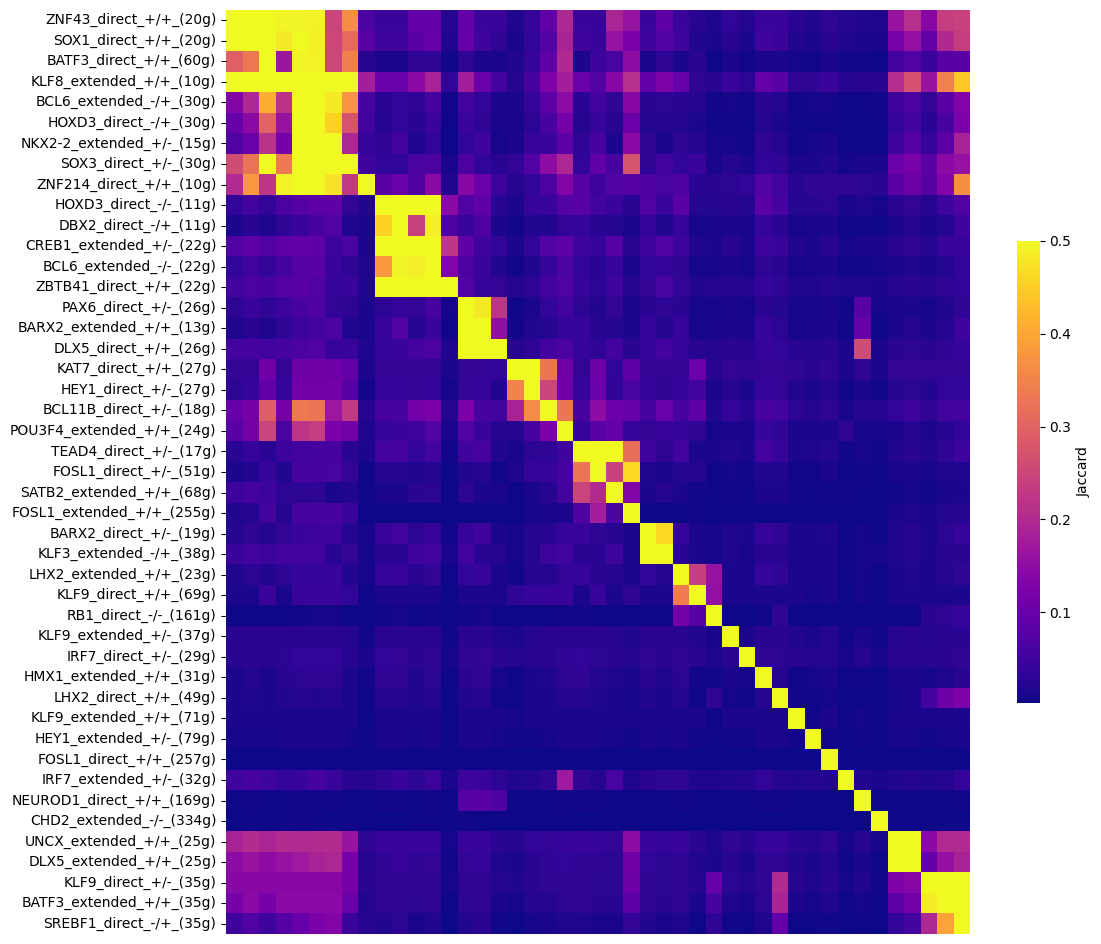

In [ ]:
region_intersetc_data, Z = jaccard_heatmap(
        scplus_obj,
        method = 'intersect',
        gene_or_region_based = 'Gene_based',
        use_plotly = False,
        selected_regulons = tfs,
        signature_key = 'eRegulon_AUC',
        figsize = (12, 12), return_data = True, vmax = 0.5, cmap = 'plasma')